In [1]:
# Milestone 4: Forecast Integration & Capacity Planning

import os
import warnings
warnings.filterwarnings("ignore")

import joblib
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# File paths
MODEL_PATH = "C:\\Users\\prust\\OneDrive\\Desktop\\Infosys Springboard\\demand_forecasting_model.pkl"
FEATURE_PATH = "C:\\Users\\prust\\OneDrive\\Desktop\\Infosys Springboard\\feature_list.pkl"
DATA_PATH ="C:\\Users\\prust\\OneDrive\\Desktop\\Infosys Springboard\\feature_engineered_dataset.csv"

# Check files
print("Model exists:", os.path.exists(MODEL_PATH))
print("Dataset exists:", os.path.exists(DATA_PATH))

# Load trained best model
best_model = joblib.load(MODEL_PATH)
print("Best model loaded successfully.")
print(best_model)

Model exists: True
Dataset exists: True
Best model loaded successfully.
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [3]:
# Load feature engineered dataset
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (315, 32)

Columns:
['time_stamp', 'region', 'service_type', 'usage_units', 'provisioned_capacity', 'cost_usd', 'availability_pct', 'economic_indicator_index', 'market_demand_index', 'product_launch_impact', 'year', 'month', 'quarter', 'week_of_year', 'is_month_start', 'is_month_end', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'rolling_std_6', 'capacity_utilization', 'growth_rate_1', 'growth_rate_4', 'spike_flag', 'region_East Us', 'region_Southeast Asia', 'region_West Europe', 'service_Storage']

First 5 rows:


,time_stamp,region,service_type,usage_units,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact,...,rolling_std_3,rolling_std_6,capacity_utilization,growth_rate_1,growth_rate_4,spike_flag,region_East Us,region_Southeast Asia,region_West Europe,service_Storage
0,2021-05-01,Central India,Compute,852.50,929.99,102.30,97.88,97.03,92.14,0,...,14.711418,45.315538,0.916677,0.004122,0.068791,0,False,False,False,False
1,2021-05-15,Central India,Compute,822.77,869.71,98.73,97.56,97.63,92.43,0,...,16.248773,20.091600,0.946028,-0.034874,-0.000644,0,False,False,False,False
2,2021-06-01,Central India,Compute,854.46,928.97,102.54,98.32,97.54,93.10,1,...,17.757489,15.541441,0.919793,0.038516,0.035144,0,False,False,False,False
3,2021-06-15,Central India,Compute,838.37,892.28,100.60,98.98,97.56,93.50,1,...,15.845631,13.831053,0.939582,-0.018831,-0.012521,0,False,False,False,False
4,2021-07-01,Central India,Compute,871.84,921.87,104.62,99.83,97.44,94.03,1,...,16.739143,16.495270,0.945730,0.039923,0.022686,0,False,False,False,False


In [4]:
# Load trained best model
model = joblib.load(MODEL_PATH)

# Load feature columns
feature_columns = joblib.load(FEATURE_PATH)

print("Model loaded successfully")
print("Model type:", type(model))
print("Number of features:", len(feature_columns))
print("First 5 feature columns:", feature_columns[:5])

Model loaded successfully
Model type: <class 'xgboost.sklearn.XGBRegressor'>
Number of features: 31
First 5 feature columns: ['provisioned_capacity', 'cost_usd', 'availability_pct', 'economic_indicator_index', 'market_demand_index']


In [5]:
# Target column
target_col = "usage_units"

# Drop columns not used for prediction
drop_cols = [target_col]

if "time_stamp" in df.columns:
    drop_cols.append("time_stamp")

X = df.drop(columns=drop_cols, errors="ignore")
y = df[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature shape: (315, 30)
Target shape: (315,)

Feature columns:
['region', 'service_type', 'provisioned_capacity', 'cost_usd', 'availability_pct', 'economic_indicator_index', 'market_demand_index', 'product_launch_impact', 'year', 'month', 'quarter', 'week_of_year', 'is_month_start', 'is_month_end', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'rolling_std_6', 'capacity_utilization', 'growth_rate_1', 'growth_rate_4', 'spike_flag', 'region_East Us', 'region_Southeast Asia', 'region_West Europe', 'service_Storage']


In [6]:
# Convert timestamp if present
if "time_stamp" in df.columns:
    df["time_stamp"] = pd.to_datetime(df["time_stamp"])
    df = df.sort_values("time_stamp").reset_index(drop=True)

print(df.dtypes)

time_stamp                  datetime64[ns]
region                              object
service_type                        object
usage_units                        float64
provisioned_capacity               float64
cost_usd                           float64
availability_pct                   float64
economic_indicator_index           float64
market_demand_index                float64
product_launch_impact                int64
year                                 int64
month                                int64
quarter                              int64
week_of_year                         int64
is_month_start                       int64
is_month_end                         int64
lag_1                              float64
lag_2                              float64
lag_4                              float64
lag_8                              float64
rolling_mean_3                     float64
rolling_mean_6                     float64
rolling_std_3                      float64
rolling_std

In [7]:
# Target column
target_col = "usage_units"

# Columns to drop for model input
drop_cols = [target_col]

if "time_stamp" in df.columns:
    drop_cols.append("time_stamp")

# Create feature matrix and target vector
X = df.drop(columns=drop_cols, errors="ignore")
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nChecking feature alignment:")
print("Saved features count:", len(feature_columns))
print("Total columns in dataset:", len(X.columns))

missing_features = set(feature_columns) - set(X.columns)

if len(missing_features) == 0:
    print("All saved features are present in dataset.")
else:
    print("Missing features:", missing_features)

Feature matrix shape: (315, 30)
Target shape: (315,)

Checking feature alignment:
Saved features count: 31
Total columns in dataset: 30
Missing features: {'service_type_Storage', 'service_type_Compute', 'region_Central India'}


In [9]:
# Check missing and extra columns
missing_cols = [col for col in feature_columns if col not in X.columns]
extra_cols = [col for col in X.columns if col not in feature_columns]

print("Missing columns:", missing_cols)
print("Extra columns:", extra_cols)

# Align current data to training feature structure
X_aligned = X.copy()

for col in feature_columns:
    if col not in X_aligned.columns:
        X_aligned[col] = 0

X_aligned = X_aligned[feature_columns]

print("Final aligned shape:", X_aligned.shape)

# Simulate new incoming demand data using latest records
latest_input = X_aligned.tail(10).copy()

# Generate predictions
latest_predictions = model.predict(latest_input)

prediction_df = latest_input.copy()
prediction_df["predicted_usage_units"] = latest_predictions

print("Real-time predictions generated successfully.")
display(prediction_df.head())

Missing columns: ['region_Central India', 'service_type_Compute', 'service_type_Storage']
Extra columns: ['region', 'service_type']
Final aligned shape: (315, 31)
Real-time predictions generated successfully.


,provisioned_capacity,cost_usd,availability_pct,economic_indicator_index,market_demand_index,product_launch_impact,year,month,quarter,week_of_year,...,growth_rate_4,spike_flag,region_East Us,region_Southeast Asia,region_West Europe,service_Storage,region_Central India,service_type_Compute,service_type_Storage,predicted_usage_units
305,1125.43,74.83,98.67,104.41,104.54,0,2022,12,4,48,...,0.034686,0,False,True,False,False,0,0,0,971.864319
306,913.76,74.83,99.49,104.41,104.54,0,2022,12,4,48,...,0.008940,0,False,False,True,False,0,0,0,816.972290
307,892.01,67.09,98.02,104.41,104.54,0,2022,12,4,48,...,-0.072131,0,False,False,False,True,0,0,0,812.940369
308,1339.87,144.08,99.03,104.38,103.69,0,2022,12,4,50,...,0.062220,0,False,False,False,False,0,0,0,1033.847778
309,1045.33,115.34,98.60,104.38,103.69,0,2022,12,4,50,...,0.021368,0,True,False,False,False,0,0,0,956.352844


In [10]:
# Add prediction timestamp
prediction_df["prediction_time"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Save output for dashboard / reporting
prediction_output_path = "prediction_service_demo.csv"
prediction_df.to_csv(prediction_output_path, index=False)

print(f"Prediction output saved to: {prediction_output_path}")

Prediction output saved to: prediction_service_demo.csv


In [11]:
# Capacity planning recommendation logic
def capacity_action(pred_value):
    if pred_value >= 900:
        return "Scale Up Capacity Immediately"
    elif pred_value >= 700:
        return "Prepare Additional Capacity"
    elif pred_value >= 500:
        return "Monitor Demand Closely"
    else:
        return "Capacity is Sufficient"

prediction_df["capacity_action"] = prediction_df["predicted_usage_units"].apply(capacity_action)

display(prediction_df[["predicted_usage_units", "capacity_action"]].head(10))

,predicted_usage_units,capacity_action
305,971.864319,Scale Up Capacity Immediately
306,816.972290,Prepare Additional Capacity
307,812.940369,Prepare Additional Capacity
308,1033.847778,Scale Up Capacity Immediately
309,956.352844,Scale Up Capacity Immediately
310,778.010681,Prepare Additional Capacity
311,763.312500,Prepare Additional Capacity
312,1031.199829,Scale Up Capacity Immediately
313,847.772888,Prepare Additional Capacity
314,690.972290,Monitor Demand Closely


In [12]:
# Create monitoring log
monitoring_log = pd.DataFrame({
    "log_time": [datetime.now().strftime("%Y-%m-%d %H:%M:%S")] * len(prediction_df),
    "model_name": ["XGBoost"] * len(prediction_df),
    "model_version": ["v1.0"] * len(prediction_df),
    "prediction_value": prediction_df["predicted_usage_units"].values,
    "recommended_action": prediction_df["capacity_action"].values
})

monitoring_log_path = "monitoring_log.csv"
monitoring_log.to_csv(monitoring_log_path, index=False)

print(f"Monitoring log saved to: {monitoring_log_path}")
display(monitoring_log.head())

Monitoring log saved to: monitoring_log.csv


,log_time,model_name,model_version,prediction_value,recommended_action
0,2026-03-23 04:38:19,XGBoost,v1.0,971.864319,Scale Up Capacity Immediately
1,2026-03-23 04:38:19,XGBoost,v1.0,816.972290,Prepare Additional Capacity
2,2026-03-23 04:38:19,XGBoost,v1.0,812.940369,Prepare Additional Capacity
3,2026-03-23 04:38:19,XGBoost,v1.0,1033.847778,Scale Up Capacity Immediately
4,2026-03-23 04:38:19,XGBoost,v1.0,956.352844,Scale Up Capacity Immediately


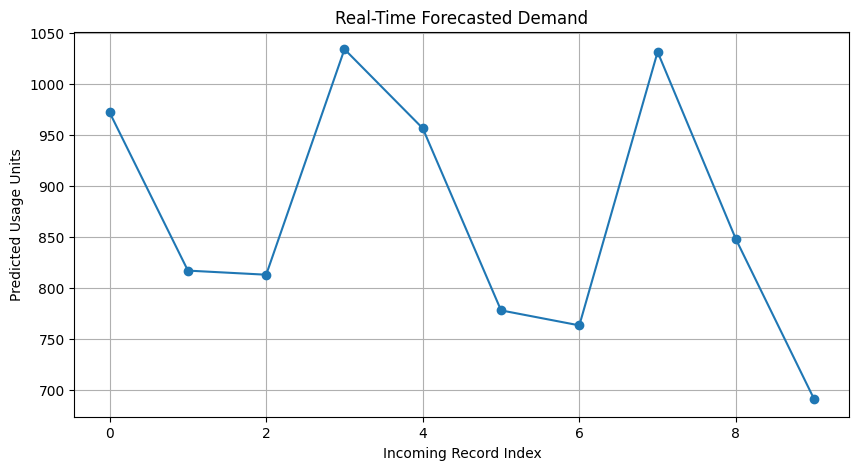

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(prediction_df["predicted_usage_units"].values, marker="o")
plt.title("Real-Time Forecasted Demand")
plt.xlabel("Incoming Record Index")
plt.ylabel("Predicted Usage Units")
plt.grid(True)
plt.show()

In [14]:
def retraining_trigger(actual_values, predicted_values, threshold=100):
    error = np.mean(np.abs(actual_values - predicted_values))
    print("Average absolute error:", round(error, 2))
    
    if error > threshold:
        print("Retraining required: Model performance has degraded.")
        return True
    else:
        print("No retraining required: Model performance is stable.")
        return False

In [15]:
# Simulated check using latest actual and predicted values
sample_actuals = y.tail(10).values
sample_preds = prediction_df["predicted_usage_units"].values

retraining_needed = retraining_trigger(sample_actuals, sample_preds)

Average absolute error: 42.43
No retraining required: Model performance is stable.


## Milestone 4 Summary

This notebook operationalizes the selected forecasting model for production-like usage.

Implemented components:
- Loaded the saved best model from Milestone 3
- Loaded the feature list for consistent deployment input
- Simulated real-time incoming demand data
- Generated real-time demand predictions
- Converted predictions into capacity planning actions
- Saved prediction outputs for dashboard integration
- Created monitoring logs for model tracking
- Added retraining trigger logic for continuous improvement

This completes the Forecast Integration & Capacity Planning workflow for Milestone 4.